# Images as N-Dimensional Arrays

In this notebook, we will work with images as N-dimensional arrays using NumPy. Since there is a variety of image formats, we will need to use another library to read/load (decode) and write/save (encode) images. We will be using the Python Image Library (PIL) in Python; also known as Pillow.

In [1]:
# install all required packages for this lab
!uv pip install -q Pillow numpy

In [2]:
# import the packages that we will use in this lab
import numpy as np
from PIL import Image

## Read and Show Images

To read an image, we need to use `Image.open()`, and to convert the image to an `np.ndarray`, we will use `np.asarray()`.

In [3]:
# download images from GitHub
username = "NaifMersal"
repo_name = "cv-for-developers-ultralytics"
for image_name in ["horse.png"]:
    !wget -O image_name "https://raw.githubusercontent.com/{username}/{repo_name}/main/slides/assets/{image_name}"

--2026-05-05 11:54:54--  https://raw.githubusercontent.com/NaifMersal/cv-for-developers-ultralytics/main/slides/assets/horse.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 230777 (225K) [image/png]
Saving to: ‘image_name’

image_name          100%[===================>] 225.37K  --.-KB/s    in 0.03s   

2026-05-05 11:54:54 (8.35 MB/s) - ‘image_name’ saved [230777/230777]



In [4]:
# load the image and view it as a NumPy array
img = Image.open("horse.png")
arr = np.asarray(img)

To show the image, we will have to convert it back to a `PIL.Image.Image` using `PIL.Image.fromarray()`.

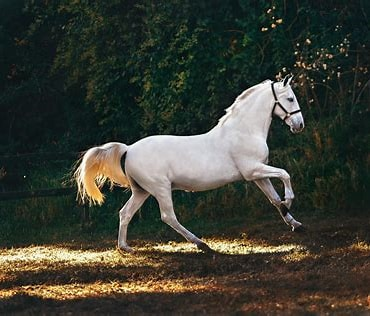

In [5]:
Image.fromarray(arr)

## Images are Arrays

Let's get the image dimensions (height, width, and number of color channels) and data type.

In [6]:
arr.shape

(316, 370, 3)

In [7]:
print(f"height   = {arr.shape[0]}")
print(f"width    = {arr.shape[1]}")
print(f"channels = {arr.shape[2]}")

height   = 316
width    = 370
channels = 3


In [8]:
arr.dtype

dtype('uint8')

As we can see, the type is uint8 (a shorthand for "unsigned 8-bit integer"). This type can take all possible values from $[0 - 255]$ (a total of $256 = 2^{8\leftarrow\text{number of bits}}$ values).

In [9]:
print(f"{arr.min() = }")
print(f"{arr.max() = }")

arr.min() = np.uint8(0)
arr.max() = np.uint8(255)


We can get the color values for any pixel by directly indexing the array.

In [10]:
y, x = 158, 185

arr[y, x]

array([202, 198, 199], dtype=uint8)

In [11]:
r, g, b = arr[y, x]
print(f"{r = }")
print(f"{g = }")
print(f"{b = }")

r = np.uint8(202)
g = np.uint8(198)
b = np.uint8(199)


## Pixel Access

It seems to be a color that is close to white (probably lies on the body of the horse). Let's change it to be red.  We will copy the image first in order to be able to modify it.

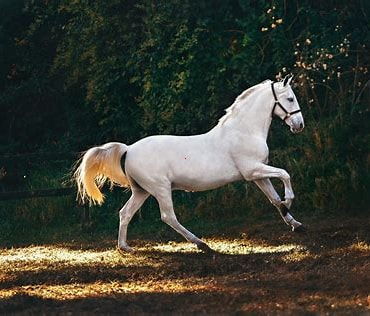

In [12]:
arr = np.asarray(img).copy()
arr[y, x] = (255, 0, 0)

Image.fromarray(arr)

Can you see the extremely small red dot on the horse's body? That is a single pixel for you. If you didn't see it yet, let's set a square of size $20\times20$ pixels to red. Maybe it will become clearer.

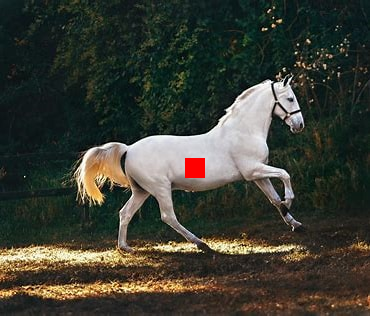

In [13]:
arr[y : y + 20, x : x + 20] = (255, 0, 0)  # we are benefiting from broadcasting here

Image.fromarray(arr)

## Crop and Paste

We can crop part of the image as we wish by slice indexing the array.

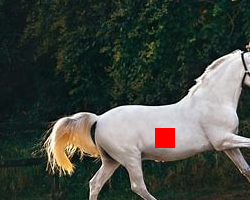

In [14]:
top, left = 30, 30
height, width = 200, 250

crop = arr[top : top + height, left : left + width]
Image.fromarray(crop)

Let's paste this crop in the top-left corner of the image.

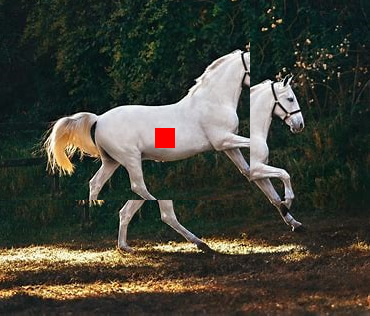

In [15]:
y, x = 0, 0

arr[y : y + height, x : x + width] = crop

Image.fromarray(arr)

### Flip

Let's flip the image upside-down.

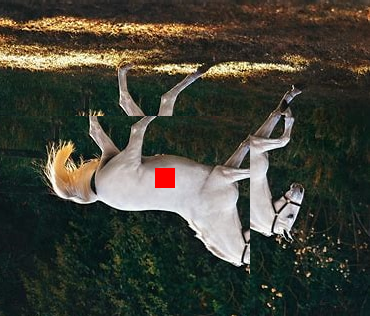

In [16]:
Image.fromarray(arr[::-1])

Or left-to-right.

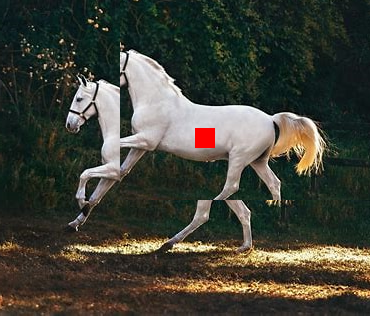

In [17]:
Image.fromarray(arr[:, ::-1])

## Invert

Let's get the negative image (like what we see in vintage camera films).

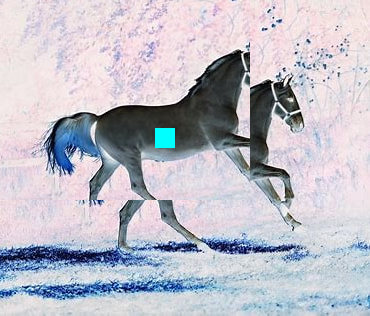

In [18]:
Image.fromarray(~arr)

> Fun exercise: if you stare long enough (~1-2 mintues) at the blue square, then you moved your gaze quickly into a white background (e.g. a white wall) and blinked repeatedly and rapidly, you will be able to see an after image with the original colors.

## Color Channels

We can extract the color bands (red, green, and blue color channels) of the image by moving the color axis (last one "-1") to be the first one "0" and unpacking the matrices into different variables.

In [19]:
r = arr[..., 0]
g = arr[..., 1]
b = arr[..., 2]

Let's remove all the red from the image by replacing it with zeros and see how the result will look like.

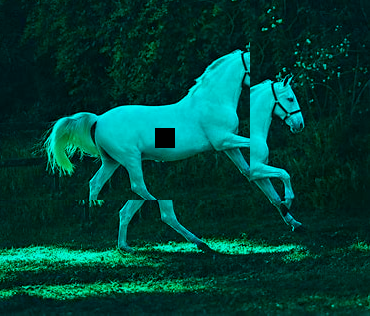

In [20]:
Image.fromarray(np.stack([r * 0, g, b], axis=-1))

> Notice how the red squares became black, and there is no red tone to the image at all.

## Grayscale

Let's convert the image into grayscale by combining all the color channels with equal weights. Notice, how we need to divide first (to convert the `dtype` to `float`). We cannot do this `(r + g + b) / 3` directly because the result of the sum of two `uint8` arrays will still be `uint8`. In such case, overflows might happen and the operations will be modulo $255$. Also, we will need to convert the result back to `unit8` to be a proper image.

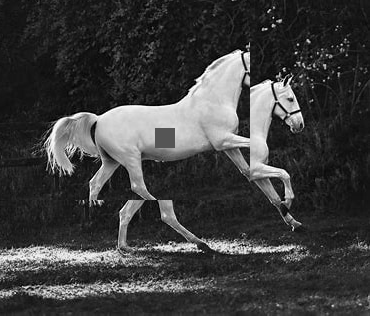

In [21]:
gray = (r / 3 + g / 3 + b / 3).astype("uint8")
Image.fromarray(gray)

This works just fine but it is [recommended](https://stackoverflow.com/a/689547) to match the color sensetivity of the human eye by using the following weights:

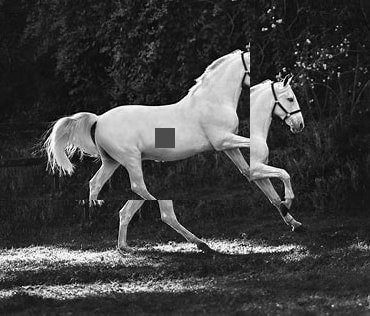

In [22]:
gray = (r * 0.299 + g * 0.587 + b * 0.114).astype("uint8")
Image.fromarray(gray)

## Thresholding

Let's do something interesting with this gray image. If you notice above, the pixels with the heighest intensity values are those pixels that belong to the horse. We can select them using a simple conditional statement (a process called thresholding).

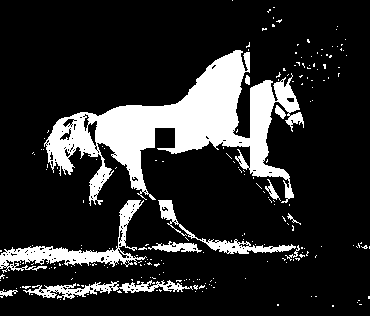

In [23]:
threshold = 128

mask = gray > threshold
Image.fromarray(mask)

Let's use this mask to hide everthing in the original image except for those pixels.

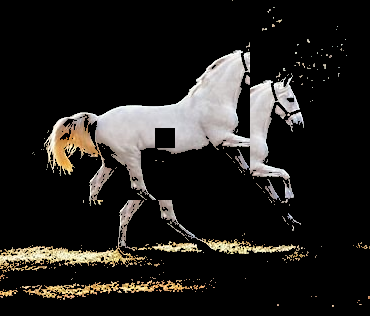

In [24]:
arr[~mask] = 0
Image.fromarray(arr)

## Your Turn

You have reached the end of this notebook. You can experiment with your newly acquired skills to do:

1. **Image Redaction**
Load an image, which contains sensitive information that needs to be redacted. Crop a rectangular region containing the sensitive text. Replace the cropped region with a solid black rectangle by manipulating the pixels.

<details>
<summary>Solution</summary>

```python
arr = np.array(Image.open('./horse.jpg'))

y, x = 185, 550
height, width = 15, 70

arr[y:y + height, x:x + width] = 0

Image.fromarray(arr).show()
```

</details>

2. **Image Tiling**
Load the provided image `tile_pattern.png`, which is a small tile or pattern image. Create a new blank canvas with dimensions five times the image. Tile the image across the canvas by repeatedly pasting it and manipulating the pixels.

![](https://github.com/NaifMersal/cv-for-developers-ultralytics/blob/main/labs/tile_pattern.png?raw=1)

<details>
<summary>Solution</summary>

```python
tile = np.asarray(Image.open('./tile_pattern.png'))

# height, width, *channels = tile.shape
# canvas = np.zeros((5 * height, 5 * width, *channels), tile.dtype)
# for i in range(0, canvas.shape[0], tile.shape[0]):
#     for j in range(0, canvas.shape[1], tile.shape[1]):
#         canvas[i:i + tile.shape[0], j:j + tile.shape[1]] = tile
# # -- OR
canvas = np.concatenate([tile] * 5, axis=0)
canvas = np.concatenate([canvas] * 5, axis=1)

Image.fromarray(canvas).show()
```

</details>

3. **Image Watermarking**
Load an image and load the provided `watermark.png` image. Paste the watermark image onto the bottom-right corner of the artwork image by manipulating the pixels. It would be awesome, if you can account for the transparency in the watermark.

![](https://github.com/NaifMersal/cv-for-developers-ultralytics/blob/main/labs/watermark.png?raw=1)

<details>
<summary>Solution</summary>

```python
arr = np.array(Image.open('./horse.jpg'))
watermark = np.asarray(Image.open('watermark.png'))

crop = arr[-watermark.shape[0]:, -watermark.shape[1]:]

crop[...] = watermark  # the Ellipsis indexing [...] writes the values inplace
# # -- OR
# mask = watermark > 0
# crop[mask] = watermark[mask]

Image.fromarray(arr).show()
```

</details>

⚠️ Remember, there are plenty of ways to achieve the same results. Don't get discouraged if your solution didn't match ours. Enjoy the journey! Happy coding ;)